In [1]:
# PASO 1: IMPORTAR Y CARGAR DATOS

# 1. Carga y Exploración Inicial del Dataset, importación de librería pandas
import pandas as pd

# 2. Configuración visual, para que se muestren todas las columnas sin importar el tamaño de la tabla
pd.set_option('display.max_columns', None)

# 3. Carga del Dataset
try:
    # Lectura del archivo CSV del dataset de lugares comunes de la ciudad
    # Asegúrate de que el nombre del archivo sea exacto
    df_Common = pd.read_csv('../../datos/crudos/lugares_interes/NYC_Common_Places.csv') 
    
    print("DIMENSIONES DEL DATASET")    
    # Visualización de la cantidad de filas y columnas del dataset
    print(f"📊 Dimensiones {df_Common.shape[0]:,} filas y {df_Common.shape[1]} columnas.")
    
    # Vista Previa de las primeras 5 filas
    print("\n--- VISUALIZACIÓN DEL CONTENIDO DEL DATASET ---")
    display(df_Common.head(5))
    
    # Información de las variables del dataset y su tipo de datos
    print("\n--- INFORMACIÓN DE VARIABLES ---")
    
    # Verificación de celdas y columnas vacías
    df_Common.info()

except FileNotFoundError:
    print("❌ ERROR: No encuentro el archivo 'NYC_Common_Places.csv' en la carpeta Datos_Crudos.")

DIMENSIONES DEL DATASET
📊 Dimensiones 20,576 filas y 21 columnas.

--- VISUALIZACIÓN DEL CONTENIDO DEL DATASET ---


,the_geom,SEGMENTID,COMPLEXID,SAFTYPE,PLACEID,BIN,SOURCE,OBJECTID,SOS INDICATOR,FACILITY DOMAINS,BOROUGH CODE,SOURCE ID,CREATED_BY,CREATED_DATE,MODIFIED_BY,MODIFIED_DATE,FACILITY TYPE,B7SC,PRIMARY ADDRESS POINT ID,FEATURE NAME,SECURITY LEVEL
0,POINT (-74.097961931446 40.634604200807),13.847,NaN,NaN,11.947,5.002.227,DOE,10.555,2.0,2,5.0,31R061,NaN,2009 May 14 12:00:00 AM,NaN,2020 Jun 18 09:27:09 AM,2,NaN,5.002.977,IS 61 WILLIAM A MORRIS,1
1,POINT (-73.981379489555 40.589105561411),19.292,NaN,NaN,12.280,3.385.667,DOE,5.120,2.0,3,3.0,75K721,NaN,2009 May 14 12:00:00 AM,NaN,2020 Apr 08 09:48:35 AM,2,NaN,5.132.738,PS 721 BROOKLYN OCCUPATIONAL TRAINING CENTER,1
2,POINT (-73.943478646583 40.724827480825),35.645,4.762,X,1.036.755,3.338.038,OTHER,20.345,2.0,10,3.0,NaN,NaN,2020 Dec 10 01:57:39 PM,NaN,2022 Oct 12 04:59:27 PM,4,31248503.0,5.201.395,MCGOLRICK PLAYGROUND COMFORT STATION,1
3,POINT (-73.858490015009 40.708424926703),151.696,NaN,NaN,3.068,4.095.037,EMS,7.507,1.0,2,4.0,NaN,NaN,2009 May 14 12:00:00 AM,NaN,2017 Feb 08 03:08:17 PM,7,NaN,105.469,HOME DEPOT WOODHAVEN BLVD,1
4,POINT (-74.024085858699 40.672444940613),17.988,NaN,NaN,6.914,NaN,NOAA,7.005,NaN,11,3.0,NaN,NaN,2009 May 14 12:00:00 AM,NaN,NaN,6,NaN,NaN,BAY RIDGE CHANNEL LIGHTED GONG BUOY 11,1



--- INFORMACIÓN DE VARIABLES ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20576 entries, 0 to 20575
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   the_geom                  20576 non-null  object 
 1   SEGMENTID                 20574 non-null  object 
 2   COMPLEXID                 7624 non-null   float64
 3   SAFTYPE                   11133 non-null  object 
 4   PLACEID                   20576 non-null  object 
 5   BIN                       14238 non-null  object 
 6   SOURCE                    20576 non-null  object 
 7   OBJECTID                  20576 non-null  float64
 8   SOS INDICATOR             19992 non-null  float64
 9   FACILITY DOMAINS          20576 non-null  int64  
 10  BOROUGH CODE              20365 non-null  float64
 11  SOURCE ID                 5882 non-null   object 
 12  CREATED_BY                983 non-null    object 
 13  CREATED_DATE              2

In [2]:
# PASO 2: SELECCIÓN Y LIMPIEZA DE COLUMNAS

# 1. Selección de las variables (columnas) estratégicas para el proyecto
lista_columnas = [
    'the_geom',          # Coordenadas (POINT)
    'FEATURE NAME',      # Nombre del lugar
    'FACILITY TYPE',     # Categoría del lugar
    'BOROUGH CODE'       # Código del distrito (1 = Manhattan)
]

try:
    # 2. Creación del dataset de las columnas seleccionadas
    df_limpio = df_Common[lista_columnas].copy()

    # 3. Renombre de las columnas para estandarizar el proyecto
    df_limpio = df_limpio.rename(columns={
        'FEATURE NAME': 'NOMBRE_LUGAR',
        'FACILITY TYPE': 'CATEGORIA',
        'BOROUGH CODE': 'ZONA'
    })

    # EXTRA: Extracción de Coordenadas (Estandarización espacial)
    coords = df_limpio['the_geom'].str.replace('POINT (', '', regex=False).str.replace(')', '', regex=False)
    
    # Dividimos por el espacio
    df_limpio['LONGITUD'] = coords.str.split(' ').str[0]
    df_limpio['LATITUD'] = coords.str.split(' ').str[1]
    
    # Eliminamos la columna geométrica original
    df_limpio = df_limpio.drop(columns=['the_geom'])

    # 4. Filtramos en ZONA el área de estudio (Código 1.0 = Manhattan)
    df_limpio = df_limpio[df_limpio['ZONA'] == 1.0]

    # 5. Visualización del resultado
    print(f"📊 Nueva dimensión {df_limpio.shape[0]:,} filas y {df_limpio.shape[1]} columnas")

    print("\n--- VISUALIZACIÓN DE PUNTOS DE INTERÉS (MANHATTAN) ---")
    display(df_limpio.head())

except KeyError as e:
    print(f"❌ ERROR: Columna no encontrada: {e}")

📊 Nueva dimensión 5,877 filas y 5 columnas

--- VISUALIZACIÓN DE PUNTOS DE INTERÉS (MANHATTAN) ---


,NOMBRE_LUGAR,CATEGORIA,ZONA,LONGITUD,LATITUD
5,THOMAS JEFFERSON PARK,4,1.0,-73.936113484306,40.793070363719
6,DALTON SCHOOL THE FIRST PROGRAM,2,1.0,-73.955888984378,40.783951563
8,STUYVESANT TOWN 321 AVE C 319 AVE C 315 AVE C,1,1.0,-73.974551138655,40.731826135591
11,HARLEM GROWN 134 ST GREEN HOUSE,4,1.0,-73.943313433901,40.81410593537
15,RIVERSIDE PARK BASKETBALL COURTS W 111 ST,4,1.0,-73.96974958994,40.806235003283


In [3]:
# PASO 3: ESTANDARIZACIÓN Y CONVERSIÓN DE TIPOS DE DATOS

# 1. NUMÉRICOS: Convertir Latitud y Longitud
cols_numericas = ['LATITUD', 'LONGITUD']

for col in cols_numericas:
    df_limpio[col] = (df_limpio[col].astype(str)
                      .str.replace(',', '.') # reemplazamos la coma por punto 
                      .str.strip())

    df_limpio[col] = pd.to_numeric(df_limpio[col], errors='coerce')


# 2. CONVERSION DE CODIGOS Y CATEGORIZACIÓN
# ZONA (Borough Code)
mapa_zona = {1.0: 'Manhattan'}

# CATEGORIA_PRINCIPAL (Facility Domains)
mapa_categorias = {
    '1': 'Residencial',
    '2': 'Educacion',
    '3': 'Cultura',
    '4': 'Parques y Jardines',
    '5': 'Servicios Sociales',
    '6': 'Infraestructura',
    '7': 'Comercial y Hoteles',
    '8': 'Administracion Publica',
    '9': 'Religion',
    '10': 'Salud',
    '11': 'Seguridad',
    '12': 'Recursos Naturales',
    '13': 'Monumentos y Plazas',
    '20': 'Transporte'
}


# Aplicamos al dataset
df_limpio['ZONA'] = df_limpio['ZONA'].map(mapa_zona)
df_limpio['CATEGORIA'] = df_limpio['CATEGORIA'].astype(str).map(mapa_categorias)


# 3 CATEGÓRICOS
# Convertimos a tipo 'category' para optimizar la base de datos
df_limpio['ZONA'] = df_limpio['ZONA'].astype('category')
df_limpio['CATEGORIA'] = df_limpio['CATEGORIA'].astype('category')

print("✅ ESTANDARIZACIÓN Y TRADUCCIÓN DE CATEGORÍAS")
print("-" * 70)
print(df_limpio.dtypes)
display(df_limpio.head(5))

✅ ESTANDARIZACIÓN Y TRADUCCIÓN DE CATEGORÍAS
----------------------------------------------------------------------
NOMBRE_LUGAR      object
CATEGORIA       category
ZONA            category
LONGITUD         float64
LATITUD          float64
dtype: object


,NOMBRE_LUGAR,CATEGORIA,ZONA,LONGITUD,LATITUD
5,THOMAS JEFFERSON PARK,Parques y Jardines,Manhattan,-73.936113,40.793070
6,DALTON SCHOOL THE FIRST PROGRAM,Educacion,Manhattan,-73.955889,40.783952
8,STUYVESANT TOWN 321 AVE C 319 AVE C 315 AVE C,Residencial,Manhattan,-73.974551,40.731826
11,HARLEM GROWN 134 ST GREEN HOUSE,Parques y Jardines,Manhattan,-73.943313,40.814106
15,RIVERSIDE PARK BASKETBALL COURTS W 111 ST,Parques y Jardines,Manhattan,-73.969750,40.806235


In [4]:
# PASO 4: ANÁLISIS DE CATEGORÍAS

print("📊 RESUMEN DE LUGARES POR CATEGORÍA EN MANHATTAN")
print("-" * 70)

# 1. Conteo de registros por Categoría General
resumen_cat = df_limpio['CATEGORIA'].value_counts(dropna=False).to_frame(name='CANTIDAD')

# 2. Cálculo de representatividad (Porcentaje)
resumen_cat['%'] = (resumen_cat['CANTIDAD'] / len(df_limpio) * 100).round(2)

display(resumen_cat)


📊 RESUMEN DE LUGARES POR CATEGORÍA EN MANHATTAN
----------------------------------------------------------------------


,CANTIDAD,%
CATEGORIA,,
Parques y Jardines,998,16.98
Educacion,970,16.51
Residencial,855,14.55
Religion,504,8.58
Infraestructura,452,7.69
Comercial y Hoteles,430,7.32
Administracion Publica,422,7.18
Servicios Sociales,375,6.38
Cultura,304,5.17


In [5]:
# PASO 5: SELECCIÓN DE CATEGORIAS

# 1. Lista de categorías estratégicas que generan flujo constante
categorias_negocio = [
    'Residencial',
    'Educacion', 
    'Comercial y Hoteles', 
    'Transporte', 
    'Monumentos y Plazas', 
    'Cultura', 
    'Parques y Jardines',
    'Administracion Publica'
]

# 2. Filtro del dataset con las categorias seleccionadas
df_final = df_limpio[df_limpio['CATEGORIA'].isin(categorias_negocio)].copy()

#3. Eliminar las categorías que ya no tienen datos (los ceros)
df_final['CATEGORIA'] = df_final['CATEGORIA'].cat.remove_unused_categories()

# 4. Resultado del filtro
print(f"📊 Registros originales (Manhattan): {len(df_limpio):,}")
print(f"🎯 Registros finales (Estratégicos): {len(df_final):,}")
print("-" * 70)

print("\n--- CATEGORÍAS QUE QUEDAN EN TU DATASET ---")
print(df_final['CATEGORIA'].value_counts())

📊 Registros originales (Manhattan): 5,877
🎯 Registros finales (Estratégicos): 4,253
----------------------------------------------------------------------

--- CATEGORÍAS QUE QUEDAN EN TU DATASET ---
CATEGORIA
Parques y Jardines        998
Educacion                 970
Residencial               855
Comercial y Hoteles       430
Administracion Publica    422
Cultura                   304
Monumentos y Plazas       274
Name: count, dtype: int64


In [6]:
# PASO 6: AUDITORÍA DE CALIDAD DE LOS DATOS (COMMON PLACES)

import numpy as np


# 1. ANÁLISIS DE VARIABLES CRÍTICAS (Coordenadas)

cols_criticas = ['LATITUD', 'LONGITUD']
nulos = df_final[cols_criticas].isnull().sum()
nulos = nulos[nulos > 0] 

if not nulos.empty:
    porcentaje = (nulos / len(df_final)) * 100
    reporte_nulos = pd.DataFrame({'Faltantes': nulos, '% Total': porcentaje})
    print(reporte_nulos.sort_values(by='% Total', ascending=False))
else:
    print("✅  No hay nulos en coordenadas ni categorías.")

# 2. AUDITORÍA ESPACIAL (Puntos en el mapa)
print("\n ANÁLISIS ESPACIAL:")

# Coordenadas en 0.0
coords_cero = (df_final['LATITUD'] == 0).sum()

print(f"-> Registros con latitud 0.0 (error): {coords_cero:,}")

# 3 ANÁLISIS DE DUPLICADOS (Para no inflar los clusters)
print("\n REGISTROS DUPLICADOS:")

duplicados = df_final.duplicated(subset=['LATITUD', 'LONGITUD', 'CATEGORIA']).sum() #lugares que tengan exactamente la misma ubicación y categoría
print(f"-> Puntos duplicados detectados: {duplicados:,}")

print("-" * 70)


✅  No hay nulos en coordenadas ni categorías.

 ANÁLISIS ESPACIAL:
-> Registros con latitud 0.0 (error): 0

 REGISTROS DUPLICADOS:
-> Puntos duplicados detectados: 0
----------------------------------------------------------------------


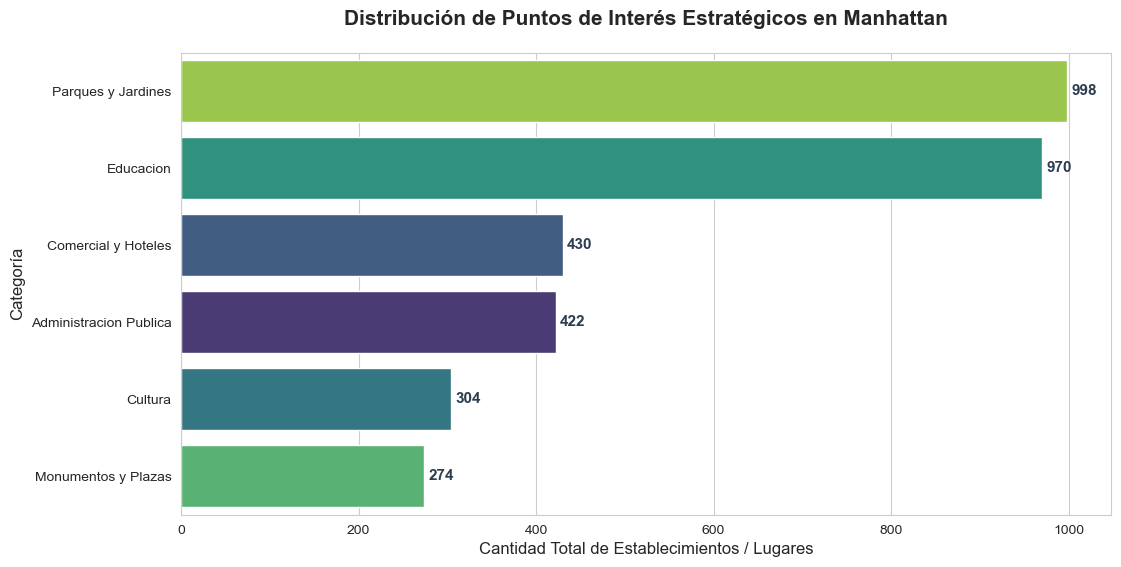

In [57]:
# PASO 7: ANÁLISIS EXPLORATORIO DE DATOS (EDA) - MTA

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuración de estilo 
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

orden_categorias = df_final['CATEGORIA'].value_counts().index # ordenado de mayor a menor

# 2. Gráfico de barras horizontales
grafico_barras = sns.countplot(
    data=df_final, 
    y='CATEGORIA', 
    order=orden_categorias, 
    hue='CATEGORIA', 
    palette="viridis", 
    legend=False      
)

# 3. Etiquetas
plt.title('Distribución de Puntos de Interés Estratégicos en Manhattan', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Cantidad Total de Establecimientos / Lugares', fontsize=12)
plt.ylabel('Categoría', fontsize=12)

# 4. Etiquetas de valor por barra
for i, v in enumerate(df_final['CATEGORIA'].value_counts()):
    plt.text(v + 5, i, f'{int(v)}', va='center', fontsize=11, fontweight='bold', color='#2c3e50')

# Mostrar gráfico
plt.show()


In [7]:
# PASO 8: EXPORTACIÓN FINAL DEL DATASET (COMMON PLACES)

import os

# Definición del nombre del archivo y ruta para guardar
carpeta = '../../datos/limpios/lugares_interes'
nombre_archivo = '11_Common_Places_Manhattan.csv'
ruta_completa = os.path.join(carpeta, nombre_archivo)


try:
    # Guardamos el CSV
    # encoding='utf-8-sig' para asegurar la correcta lectura de caracteres especiales
    df_final.to_csv(ruta_completa, index=False, encoding='utf-8-sig')
    
    print(f"\n💾 ¡EXPORTACIÓN EXITOSA!")
    print("-" * 70)
    print(f"📂 Archivo guardado en: {ruta_completa}")
    print(f"📊 Filas exportadas: {df_final.shape[0]:,}")

except Exception as e:
    print(f"❌ Error al guardar el archivo: {e}")


💾 ¡EXPORTACIÓN EXITOSA!
----------------------------------------------------------------------
📂 Archivo guardado en: Datos_Limpios\11_Common_Places_Manhattan.csv
📊 Filas exportadas: 4,253
